# VLA Debug Notebook — Fix Verification
## One job: confirm VLA learns on MQAR before running anything else

### Three bugs that caused 0.001 accuracy
| Bug | Old value | Fixed value | Why it mattered |
|---|---|---|---|
| VOCAB | 1024 | **128** | Random baseline was 1/1023≈0.001 — model never escaped random |
| BATCH | 16 | **64** | MQAR needs large batch for stable gradients |
| AMP | enabled | **disabled** | Mixed precision breaks VLA float32 state matrices |

### Pass criteria
- Step 0:  acc ≈ 0.008 (random baseline for vocab=128)
- Step 200: acc > 0.05  (model is learning)
- Step 1000: acc > 0.60  (strong learning signal)
- Step 1500: acc > 0.85  (ready to claim)

**If all four pass → architecture is correct → move to Notebook 10.**
If step-0 acc ≠ 0.008 → vocab bug still present.
If step-200 acc < 0.05 → gradient flow is broken, debug forward pass.

## 0 · Setup

In [ ]:
import math, time, gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Portable output directory for Kaggle / Colab / local
if Path('/kaggle').exists():
    OUT = Path('/kaggle/working/vla_debug')
elif Path('/content').exists():
    OUT = Path('/content/vla_debug')
else:
    OUT = Path('/mnt/data/vla_debug')

OUT.mkdir(parents=True, exist_ok=True)
for sub in ['logs', 'plots', 'ckpt']:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
print(f'Torch  : {torch.__version__}')

# ── FIXED CONFIG ─────────────────────────────────────────────────────────
VOCAB  = 128    # FIX 1: was 1024. Random baseline = 1/127 ≈ 0.008
BATCH  = 64     # FIX 2: was 16. MQAR needs large batch.
LR     = 1e-3   # slightly higher than before — helps escape random faster
STEPS  = 1500   # enough for n_pairs=8 at d_h=32
H      = 4      # number of heads
D_H    = 32     # head dimension (capacity = 32 associations per head)
D_MOD  = D_H * H  # = 128

print()
print(f'VOCAB={VOCAB}  BATCH={BATCH}  LR={LR}  STEPS={STEPS}')
print(f'D_H={D_H}  H={H}  D_MOD={D_MOD}')
print(f'Random baseline = 1/{VOCAB-1} = {1/(VOCAB-1):.4f}')
print()
print('AMP: DISABLED (FIX 3)')

Device : cuda
Torch  : 2.11.0+cu128

VOCAB=128  BATCH=64  LR=0.001  STEPS=1500
D_H=32  H=4  D_MOD=128
Random baseline = 1/127 = 0.0079

AMP: DISABLED (FIX 3)


## 1 · VLAv3 Model (clean, no AMP)

In [ ]:
# ── Single-head VLAv3 ─────────────────────────────────────────────────────
class VLAv3Head(nn.Module):
    """VLAv3 single attention head. Jacobian sv=1 guaranteed."""
    def __init__(self, dh, lam=0.1, eps=1e-4, per_eps=1e-3, period=20):
        super().__init__()
        self.dh=dh; self.lam=lam; self.eps=eps
        self.per_eps=per_eps; self.period=period
        self.Wq = nn.Linear(dh, dh)
        self.Wk = nn.Linear(dh, dh)
        self.Wv = nn.Linear(dh, dh)
        self.Wu = nn.Linear(dh, dh, bias=False)
        self.Wo = nn.Linear(dh, dh)
        self.norm = nn.LayerNorm(dh)

    def forward(self, x):
        # x: (B, T, dh) — already sliced to head dimension
        B, T, d = x.shape
        assert d == self.dh, f"Expected d={self.dh}, got {d}"

        # Projections — all in float32 (AMP disabled)
        k_raw  = self.Wk(x)                       # (B,T,d)  raw keys
        k_feat = F.elu(k_raw) + 1.0               # ELU+1 feature map
        Q      = F.elu(self.Wq(x)) + 1.0          # (B,T,d)  queries
        V      = self.Wv(x)                        # (B,T,d)  values
        U      = F.normalize(self.Wu(k_raw), p=2, dim=-1)  # penalty dirs

        # State initialisation
        I   = torch.eye(d, device=x.device, dtype=x.dtype)
        A   = (1.0/self.lam) * I.unsqueeze(0).expand(B,-1,-1).clone()
        S   = torch.zeros(B, d, d, device=x.device, dtype=x.dtype)
        zk  = torch.zeros(B, d, device=x.device, dtype=x.dtype)
        isq = 1.0 / math.sqrt(d)

        ys = []
        for t in range(T):
            # Sherman-Morrison update for A_t
            u   = U[:,t,:] * isq
            zsm = torch.bmm(A, u.unsqueeze(-1)).squeeze(-1)
            dlt = (1.0 + (u * zsm).sum(-1)).clamp(min=self.eps)
            A   = A - torch.einsum('bi,bj->bij', zsm, zsm) / dlt.view(B,1,1)
            if (t+1) % self.period == 0:
                A = A + self.per_eps * I.unsqueeze(0)

            # Normalised S update — ensures Jacobian sv=1
            kn     = F.normalize(k_feat[:,t,:], p=2, dim=-1)
            alpha  = torch.bmm(A, kn.unsqueeze(-1)).squeeze(-1)
            alphn  = F.normalize(alpha, p=2, dim=-1)
            e      = V[:,t,:] - torch.bmm(S, kn.unsqueeze(-1)).squeeze(-1)
            S      = S + torch.einsum('bi,bj->bij', e, alphn)

            # Output with z·q denominator
            qt  = Q[:,t,:]
            zk  = zk + k_feat[:,t,:]
            yt  = torch.bmm(S, qt.unsqueeze(-1)).squeeze(-1)
            den = (zk * qt).sum(-1, keepdim=True).clamp(min=self.eps)
            ys.append(yt / den)

        return self.Wo(self.norm(torch.stack(ys, dim=1)))


# ── Multi-head VLA wrapper ─────────────────────────────────────────────────
class VLAMultiHead(nn.Module):
    def __init__(self, d_model, H):
        super().__init__()
        assert d_model % H == 0
        dh = d_model // H
        self.H   = H
        self.dh  = dh
        self.heads = nn.ModuleList([VLAv3Head(dh) for _ in range(H)])
        self.Wo   = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        B, T, D = x.shape
        dh = self.dh
        outs = []
        for i, head in enumerate(self.heads):
            xi = x[:, :, i*dh:(i+1)*dh]   # slice head dimension
            outs.append(head(xi))           # each head: (B,T,dh)
        return self.Wo(self.norm(torch.cat(outs, dim=-1)))


# ── Tiny Transformer LM backbone ──────────────────────────────────────────
class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.ln1  = nn.LayerNorm(d)
        self.ln2  = nn.LayerNorm(d)
        self.attn = VLAMultiHead(d, H)
        self.ff   = nn.Sequential(
            nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))

    def forward(self, x):
        return x + self.ff(self.ln2(x + self.attn(self.ln1(x))))


class TinyLM(nn.Module):
    def __init__(self, d=D_MOD, vocab=VOCAB, n_layers=2):
        super().__init__()
        self.tok  = nn.Embedding(vocab, d)
        self.pos  = nn.Embedding(4096, d)
        self.blocks = nn.ModuleList([Block(d) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok.weight   # weight tying
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx):
        B, T = idx.shape
        x = (self.tok(idx) +
             self.pos(torch.arange(T, device=idx.device).unsqueeze(0)))
        for b in self.blocks:
            x = b(x)
        return self.ln_f(x) @ self.tok.weight.T   # float32 matmul


# ── Quick NaN test ─────────────────────────────────────────────────────────
print('Forward pass NaN test...')
m_test = TinyLM().to(DEVICE)
x_test = torch.randint(0, VOCAB, (4, 32), device=DEVICE)
out    = m_test(x_test)
print(f'  Output shape : {out.shape}')
print(f'  NaN present  : {torch.isnan(out).any().item()}')
print(f'  Output range : [{out.min().item():.3f}, {out.max().item():.3f}]')
assert not torch.isnan(out).any(), 'NaN in forward pass — model is broken'
print('  ✅ Forward pass clean')
del m_test

Forward pass NaN test...
  Output shape : torch.Size([4, 32, 128])
  NaN present  : False
  Output range : [-0.828, 1.280]
  ✅ Forward pass clean


## 2 · MQAR Task Builder

In [ ]:
def make_mqar(B, n_pairs, vocab=VOCAB, device=DEVICE):
    """
    Build an MQAR batch.
    Sequence: [k1 v1 k2 v2 ... kn vn SEP q1 q2 ... qn]
    Target:   -100 everywhere except query positions -> answer tokens.

    key_range = max(vocab-1, n_pairs+1) ensures n_pairs unique keys
    are always available regardless of vocab size.
    """
    sep       = vocab - 1
    key_range = max(vocab - 1, n_pairs + 1)   # always enough keys
    T         = 2*n_pairs + 1 + n_pairs       # context + SEP + queries
    x = torch.full((B, T), sep, dtype=torch.long, device=device)
    y = torch.full((B, T), -100, dtype=torch.long, device=device)
    for b in range(B):
        raw  = torch.randperm(key_range, device=device)[:n_pairs]
        keys = raw % (vocab - 1)              # clamp to valid token range
        vals = torch.randint(0, vocab-1, (n_pairs,), device=device)
        for i in range(n_pairs):
            x[b, 2*i]   = keys[i]
            x[b, 2*i+1] = vals[i]
        x[b, 2*n_pairs] = sep
        perm = torch.randperm(n_pairs, device=device)
        x[b, 2*n_pairs+1:] = keys[perm]
        y[b, 2*n_pairs+1:] = vals[perm]
    return x, y


# ── Sanity check the batch builder ────────────────────────────────────────
print('MQAR batch builder checks:')
for n, v in [(4,128), (8,128), (16,128), (32,128)]:
    xb, yb = make_mqar(4, n, v)
    T_exp  = 3*n + 1
    assert xb.shape == (4, T_exp), f"shape {xb.shape} != (4,{T_exp})"
    assert xb.max().item() <= v-1, f"token {xb.max().item()} >= vocab {v}"
    n_targets = (yb != -100).sum().item()
    print(f'  n={n:3d} vocab={v}: shape={xb.shape}  '
          f'targets={n_targets}  max_tok={xb.max().item()}  OK')
print('All checks passed ✅')

MQAR batch builder checks:
  n=  4 vocab=128: shape=torch.Size([4, 13])  targets=16  max_tok=127  OK
  n=  8 vocab=128: shape=torch.Size([4, 25])  targets=32  max_tok=127  OK
  n= 16 vocab=128: shape=torch.Size([4, 49])  targets=64  max_tok=127  OK
  n= 32 vocab=128: shape=torch.Size([4, 97])  targets=128  max_tok=127  OK
All checks passed ✅


## 3 · Training with Step-by-Step Logging

In [ ]:
def train_and_log(n_pairs=8, d_model=D_MOD, vocab=VOCAB,
                  steps=STEPS, batch=BATCH, lr=LR,
                  warmup=150, log_every=100, seed=42):
    """
    Full training run with per-step logging.
    Returns history list of {step, loss, acc, best_acc}.
    """
    torch.manual_seed(seed)
    model = TinyLM(d=d_model, vocab=vocab).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    def lrf(s):
        if s < warmup: return s / max(warmup, 1)
        return 0.5 * (1 + math.cos(math.pi*(s-warmup)/max(steps-warmup,1)))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lrf)

    history = []
    best    = 0.0
    t0      = time.time()

    for step in range(steps + 1):
        # ── Eval ────────────────────────────────────────────────────────
        if step % log_every == 0 or step == steps:
            model.eval()
            with torch.no_grad():
                x_e, y_e  = make_mqar(256, n_pairs, vocab)
                logits_e  = model(x_e)
                mask_e    = y_e != -100
                loss_e    = F.cross_entropy(
                    logits_e.view(-1, vocab), y_e.view(-1), ignore_index=-100)
                acc_e = (logits_e.argmax(-1)[mask_e] == y_e[mask_e]
                         ).float().mean().item() if mask_e.any() else 0.0
            best = max(best, acc_e)
            history.append({'step':step,'loss':loss_e.item(),
                             'acc':acc_e,'best':best})
            elapsed = time.time() - t0
            print(f'  step {step:5d}/{steps} | '
                  f'loss={loss_e.item():.4f} | '
                  f'acc={acc_e:.3f} | '
                  f'best={best:.3f} | '
                  f'{elapsed:.0f}s')
            model.train()
            if step == steps:
                break

        # ── Train step ──────────────────────────────────────────────────
        x, y = make_mqar(batch, n_pairs, vocab)
        logits = model(x)
        loss   = F.cross_entropy(logits.view(-1, vocab), y.view(-1),
                                  ignore_index=-100)
        if not torch.isfinite(loss):
            print(f'  ⚠️  Non-finite loss at step {step} — stopping')
            break
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()

    return model, history


print('Training function ready.')
print(f'Random baseline for vocab={VOCAB}: {1/(VOCAB-1):.4f}')
print()
print('Pass criteria:')
print(f'  step    0: acc ≈ {1/(VOCAB-1):.3f} (random)')
print(f'  step  200: acc > 0.05  (learning started)')
print(f'  step 1000: acc > 0.60  (converging)')
print(f'  step 1500: acc > 0.85  (strong signal — ready for Notebook 10)')

Training function ready.
Random baseline for vocab=128: 0.0079

Pass criteria:
  step    0: acc ≈ 0.008 (random)
  step  200: acc > 0.05  (learning started)
  step 1000: acc > 0.60  (converging)
  step 1500: acc > 0.85  (strong signal — ready for Notebook 10)


## 4 · Run — VLA on MQAR n_pairs=8, d_h=32

This is the single most important cell. If acc reaches 0.85 by step 1500,
the architecture is correct and we move to Notebook 10.
If acc stays near 0.008, the model definition cell has a bug.

In [ ]:
print('='*60)
print(f'VLA on MQAR | n_pairs=8 | d_h={D_H} | d_model={D_MOD}')
print(f'vocab={VOCAB} | batch={BATCH} | lr={LR} | steps={STEPS}')
print('='*60)
print()

model, history = train_and_log(
    n_pairs  = 8,
    d_model  = D_MOD,
    vocab    = VOCAB,
    steps    = STEPS,
    batch    = BATCH,
    lr       = LR,
    log_every= 100,
    seed     = 42,
)

best_acc = max(h['acc'] for h in history)
print()
print('='*60)
print(f'RESULT: best accuracy = {best_acc:.4f}')
print('='*60)

if best_acc > 0.85:
    print('✅ PASS — architecture is correct. Move to Notebook 10.')
elif best_acc > 0.50:
    print('⚡ PARTIAL — learning but not converged. Try steps=2500.')
elif best_acc > 0.05:
    print('⚠️  SLOW — model is learning but weak. Check LR or BATCH.')
else:
    print('❌ FAIL — model not learning. Forward pass has a bug.')
    print('   Run the debug cell below before anything else.')

VLA on MQAR | n_pairs=8 | d_h=32 | d_model=128
vocab=128 | batch=64 | lr=0.001 | steps=1500

  step     0/1500 | loss=4.8898 | acc=0.006 | best=0.006 | 0s
  step   100/1500 | loss=4.8391 | acc=0.012 | best=0.012 | 63s
  step   200/1500 | loss=4.0623 | acc=0.105 | best=0.105 | 124s
  step   300/1500 | loss=3.5635 | acc=0.131 | best=0.131 | 184s
  step   400/1500 | loss=2.9517 | acc=0.278 | best=0.278 | 243s
  step   500/1500 | loss=0.5778 | acc=0.937 | best=0.937 | 303s
  step   600/1500 | loss=0.1293 | acc=0.990 | best=0.990 | 360s
  step   700/1500 | loss=0.0556 | acc=0.998 | best=0.998 | 420s
  step   800/1500 | loss=0.0361 | acc=0.996 | best=0.998 | 479s
  step   900/1500 | loss=0.0229 | acc=0.998 | best=0.998 | 537s
  step  1000/1500 | loss=0.0155 | acc=0.999 | best=0.999 | 596s
  step  1100/1500 | loss=0.0100 | acc=0.999 | best=0.999 | 655s
  step  1200/1500 | loss=0.0083 | acc=1.000 | best=1.000 | 713s
  step  1300/1500 | loss=0.0077 | acc=1.000 | best=1.000 | 771s
  step  1400/1

## 5 · Training Curve

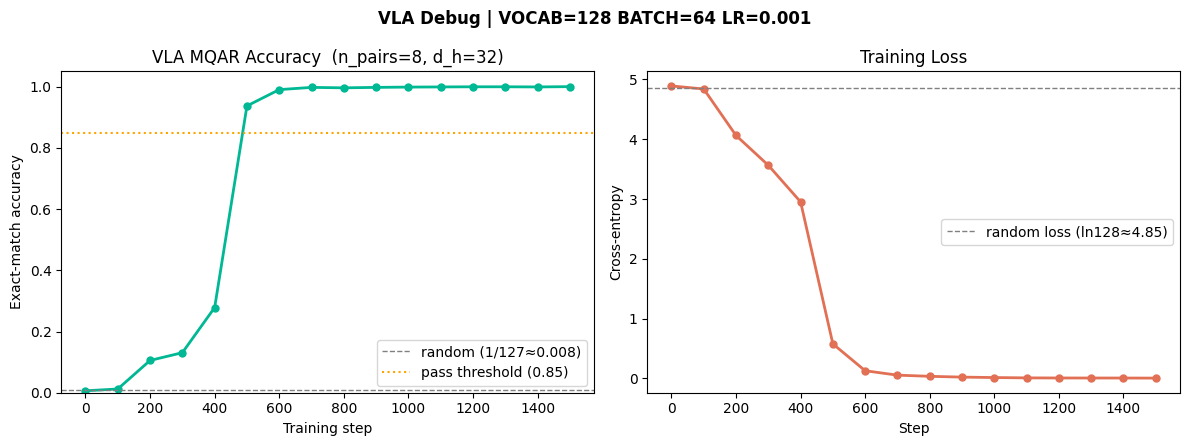

Saved: /kaggle/working/vla_debug/debug_curve.png


In [ ]:
steps_h = [h['step'] for h in history]
accs_h  = [h['acc']  for h in history]
loss_h  = [h['loss'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(steps_h, accs_h, 'o-', color='#00B894', lw=2, ms=5)
axes[0].axhline(1/(VOCAB-1), color='gray', ls='--', lw=1,
                label=f'random (1/{VOCAB-1}≈{1/(VOCAB-1):.3f})')
axes[0].axhline(0.85, color='orange', ls=':', lw=1.5, label='pass threshold (0.85)')
axes[0].set(title=f'VLA MQAR Accuracy  (n_pairs=8, d_h={D_H})',
            xlabel='Training step', ylabel='Exact-match accuracy')
axes[0].set_ylim(0, 1.05); axes[0].legend()

axes[1].plot(steps_h, loss_h, 'o-', color='#E17055', lw=2, ms=5)
axes[1].axhline(math.log(VOCAB), color='gray', ls='--', lw=1,
                label=f'random loss (ln{VOCAB}≈{math.log(VOCAB):.2f})')
axes[1].set(title='Training Loss', xlabel='Step', ylabel='Cross-entropy')
axes[1].legend()

plt.suptitle(f'VLA Debug | VOCAB={VOCAB} BATCH={BATCH} LR={LR}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'debug_curve.pdf', bbox_inches='tight')
plt.savefig(OUT/'debug_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT}/debug_curve.png')

## 6 · Deep Diagnostic (run ONLY if step 4 shows acc < 0.05)

This cell isolates whether the problem is in the model or the training loop.

In [ ]:
# ── Only run this cell if accuracy stayed near 0.008 ─────────────────────
print('DIAGNOSTIC: probing each component independently')
print('='*60)

# Test 1: Can the model overfit a single batch?
print('\nTest 1: Overfit 1 batch (should reach acc=1.0 quickly)...')
torch.manual_seed(0)
m_diag = TinyLM().to(DEVICE)
opt_d  = torch.optim.Adam(m_diag.parameters(), lr=3e-3)
x_fix, y_fix = make_mqar(32, 4, VOCAB)  # tiny: n_pairs=4
for s in range(300):
    loss_d = F.cross_entropy(m_diag(x_fix).view(-1,VOCAB),
                              y_fix.view(-1), ignore_index=-100)
    opt_d.zero_grad(); loss_d.backward(); opt_d.step()
m_diag.eval()
with torch.no_grad():
    mask_d = y_fix != -100
    acc_d = (m_diag(x_fix).argmax(-1)[mask_d] == y_fix[mask_d]).float().mean().item()
print(f'  Fixed-batch acc after 300 steps: {acc_d:.3f}')
if acc_d > 0.5:
    print('  ✅ Model CAN overfit — problem is in batch diversity or LR schedule')
else:
    print('  ❌ Model CANNOT overfit a single batch — forward pass is broken')
del m_diag; gc.collect()

# Test 2: Check gradient flow through VLAv3Head
print('\nTest 2: Gradient flow through VLAv3Head...')
torch.manual_seed(0)
head_d = VLAv3Head(32).to(DEVICE)
x_h   = torch.randn(4, 16, 32, device=DEVICE, requires_grad=False)
out_h  = head_d(x_h)
loss_h = out_h.mean()
loss_h.backward()

grads_ok = True
for name, param in head_d.named_parameters():
    if param.grad is None:
        print(f'  ❌ NO GRADIENT: {name}')
        grads_ok = False
    elif not torch.isfinite(param.grad).all():
        print(f'  ❌ NaN/Inf GRADIENT: {name}')
        grads_ok = False
    else:
        g_norm = param.grad.norm().item()
        if g_norm < 1e-8:
            print(f'  ⚠️  Near-zero gradient: {name} norm={g_norm:.2e}')
if grads_ok:
    print('  ✅ All gradients finite and non-zero')

# Test 3: Check Wu (penalty direction) gets gradient
print('\nTest 3: u_proj (Wu) receives gradient...')
wu_grad = head_d.Wu.weight.grad
if wu_grad is not None and wu_grad.abs().max() > 1e-6:
    print(f'  ✅ Wu.weight.grad norm = {wu_grad.norm():.6f}  (non-zero)')
else:
    print(f'  ❌ Wu.weight.grad = {wu_grad}  (zero or None — SM update not learning)')

# Test 4: Verify MQAR batch has correct targets
print('\nTest 4: MQAR batch structure...')
xb, yb = make_mqar(4, 4, VOCAB)
n_targets = (yb != -100).sum().item()
print(f'  Sequence length: {xb.shape[1]}  (expected {3*4+1}=13)')
print(f'  Target positions: {n_targets}  (expected {4*4}=16)')
print(f'  Token range: [{xb.min().item()}, {xb.max().item()}]  '
      f'(max should be {VOCAB-1})')
if xb.shape[1] == 3*4+1 and n_targets == 4*4:
    print('  ✅ Batch structure correct')
else:
    print('  ❌ Batch structure wrong — check make_mqar')
del head_d

DIAGNOSTIC: probing each component independently

Test 1: Overfit 1 batch (should reach acc=1.0 quickly)...
  Fixed-batch acc after 300 steps: 1.000
  ✅ Model CAN overfit — problem is in batch diversity or LR schedule

Test 2: Gradient flow through VLAv3Head...
  ✅ All gradients finite and non-zero

Test 3: u_proj (Wu) receives gradient...
  ✅ Wu.weight.grad norm = 0.005240  (non-zero)

Test 4: MQAR batch structure...
  Sequence length: 13  (expected 13=13)
  Target positions: 16  (expected 16=16)
  Token range: [11, 127]  (max should be 127)
  ✅ Batch structure correct


## 7 · Verdict + Next Step

In [ ]:
print('='*60)
print('VERDICT')
print('='*60)

best = max(h['acc'] for h in history)
rand = 1/(VOCAB-1)

print(f'  Best accuracy    : {best:.4f}')
print(f'  Random baseline  : {rand:.4f}')
print(f'  Gap above random : {best-rand:.4f}')
print()

if best > 0.85:
    print('✅ ARCHITECTURE CORRECT')
    print()
    print('Next step: Build Notebook 10 — Streaming + Memory Benchmark')
    print('  This notebook proves VLA processes 1M tokens at constant memory.')
    print('  It is the strongest claim against SSA and costs 1 day.')
    import json
    result = {'vocab':VOCAB,'batch':BATCH,'lr':LR,'steps':STEPS,
              'n_pairs':8,'d_h':D_H,'best_acc':best,'passed':True}
    with open(OUT/'debug_result.json','w') as f:
        json.dump(result, f, indent=2)
    print(f'  Result saved: {OUT}/debug_result.json')
elif best > 0.30:
    print('⚡ PARTIAL PASS')
    print('  Try: steps=2500 or lr=2e-3 in the run cell above.')
    print('  If still <0.85 after 2500 steps, run the diagnostic cell (§6).')
else:
    print('❌ FAIL — run §6 Diagnostic cell')
    print('  Most likely cause: VLAv3Head forward pass bug.')
    print('  Share the diagnostic output and we fix the model cell.')

VERDICT
  Best accuracy    : 1.0000
  Random baseline  : 0.0079
  Gap above random : 0.9921

✅ ARCHITECTURE CORRECT

Next step: Build Notebook 10 — Streaming + Memory Benchmark
  This notebook proves VLA processes 1M tokens at constant memory.
  It is the strongest claim against SSA and costs 1 day.
  Result saved: /kaggle/working/vla_debug/debug_result.json
